### Diagram for paper of Augmentations



In [4]:
# Augmetations.
from augment_utils import *


import torch
import numpy as np
from config import Augmentation_config

# Create a sample image tensor (4D: [channels, height, width, depth])
# Using random values for demonstration
sample_img = torch.randn(4, 96, 96, 96)  # 4 modalities, 96x96x96 volume

# Create sample masks
pathology_label = torch.zeros(1, 96, 96, 96)  # Single channel pathology mask
brain_mask = torch.ones(1, 96, 96, 96)  # Single channel brain mask

# Add a simulated tumor region in the pathology mask
pathology_label[:, 40:60, 40:60, 40:60] = 1

# Create augmentation config
aug_config = Augmentation_config()
aug_config.prob_brain_invert = 0.5
aug_config.prob_brain_mixup = 0.5
aug_config.prob_pathology_switch = 0.5
aug_config.prob_pathology_invert = 0.5
aug_config.prob_pathology_mixup = 0.5
aug_config.prob_brain_scale_shift = True
aug_config.prob_tumor_scale_shift = True
aug_config.uniform_scale_shift = False
aug_config.brain_factor_multiply = (0.5, 1.5)
aug_config.brain_factor_intensity = (-0.2, 0.2)
aug_config.tumor_factor_multiply = (0.5, 1.5)
aug_config.tumor_factor_intensity = (-0.2, 0.2)

# Select which channel to augment (e.g., FLAIR channel)
channel_add = [0]  # First channel

# Apply augmentation
augmented_img = spatial_contrast_aug(
    aug_config=aug_config,
    channel_add=channel_add,
    pathology_label=pathology_label,
    brain_mask=brain_mask,
    batch_img=sample_img,
    plot_image=True  # Enable visualization
)






Image shape: torch.Size([4, 240, 240, 155])
Segmentation shape: torch.Size([1, 240, 240, 155])
Brain mask shape: torch.Size([1, 240, 240, 155])


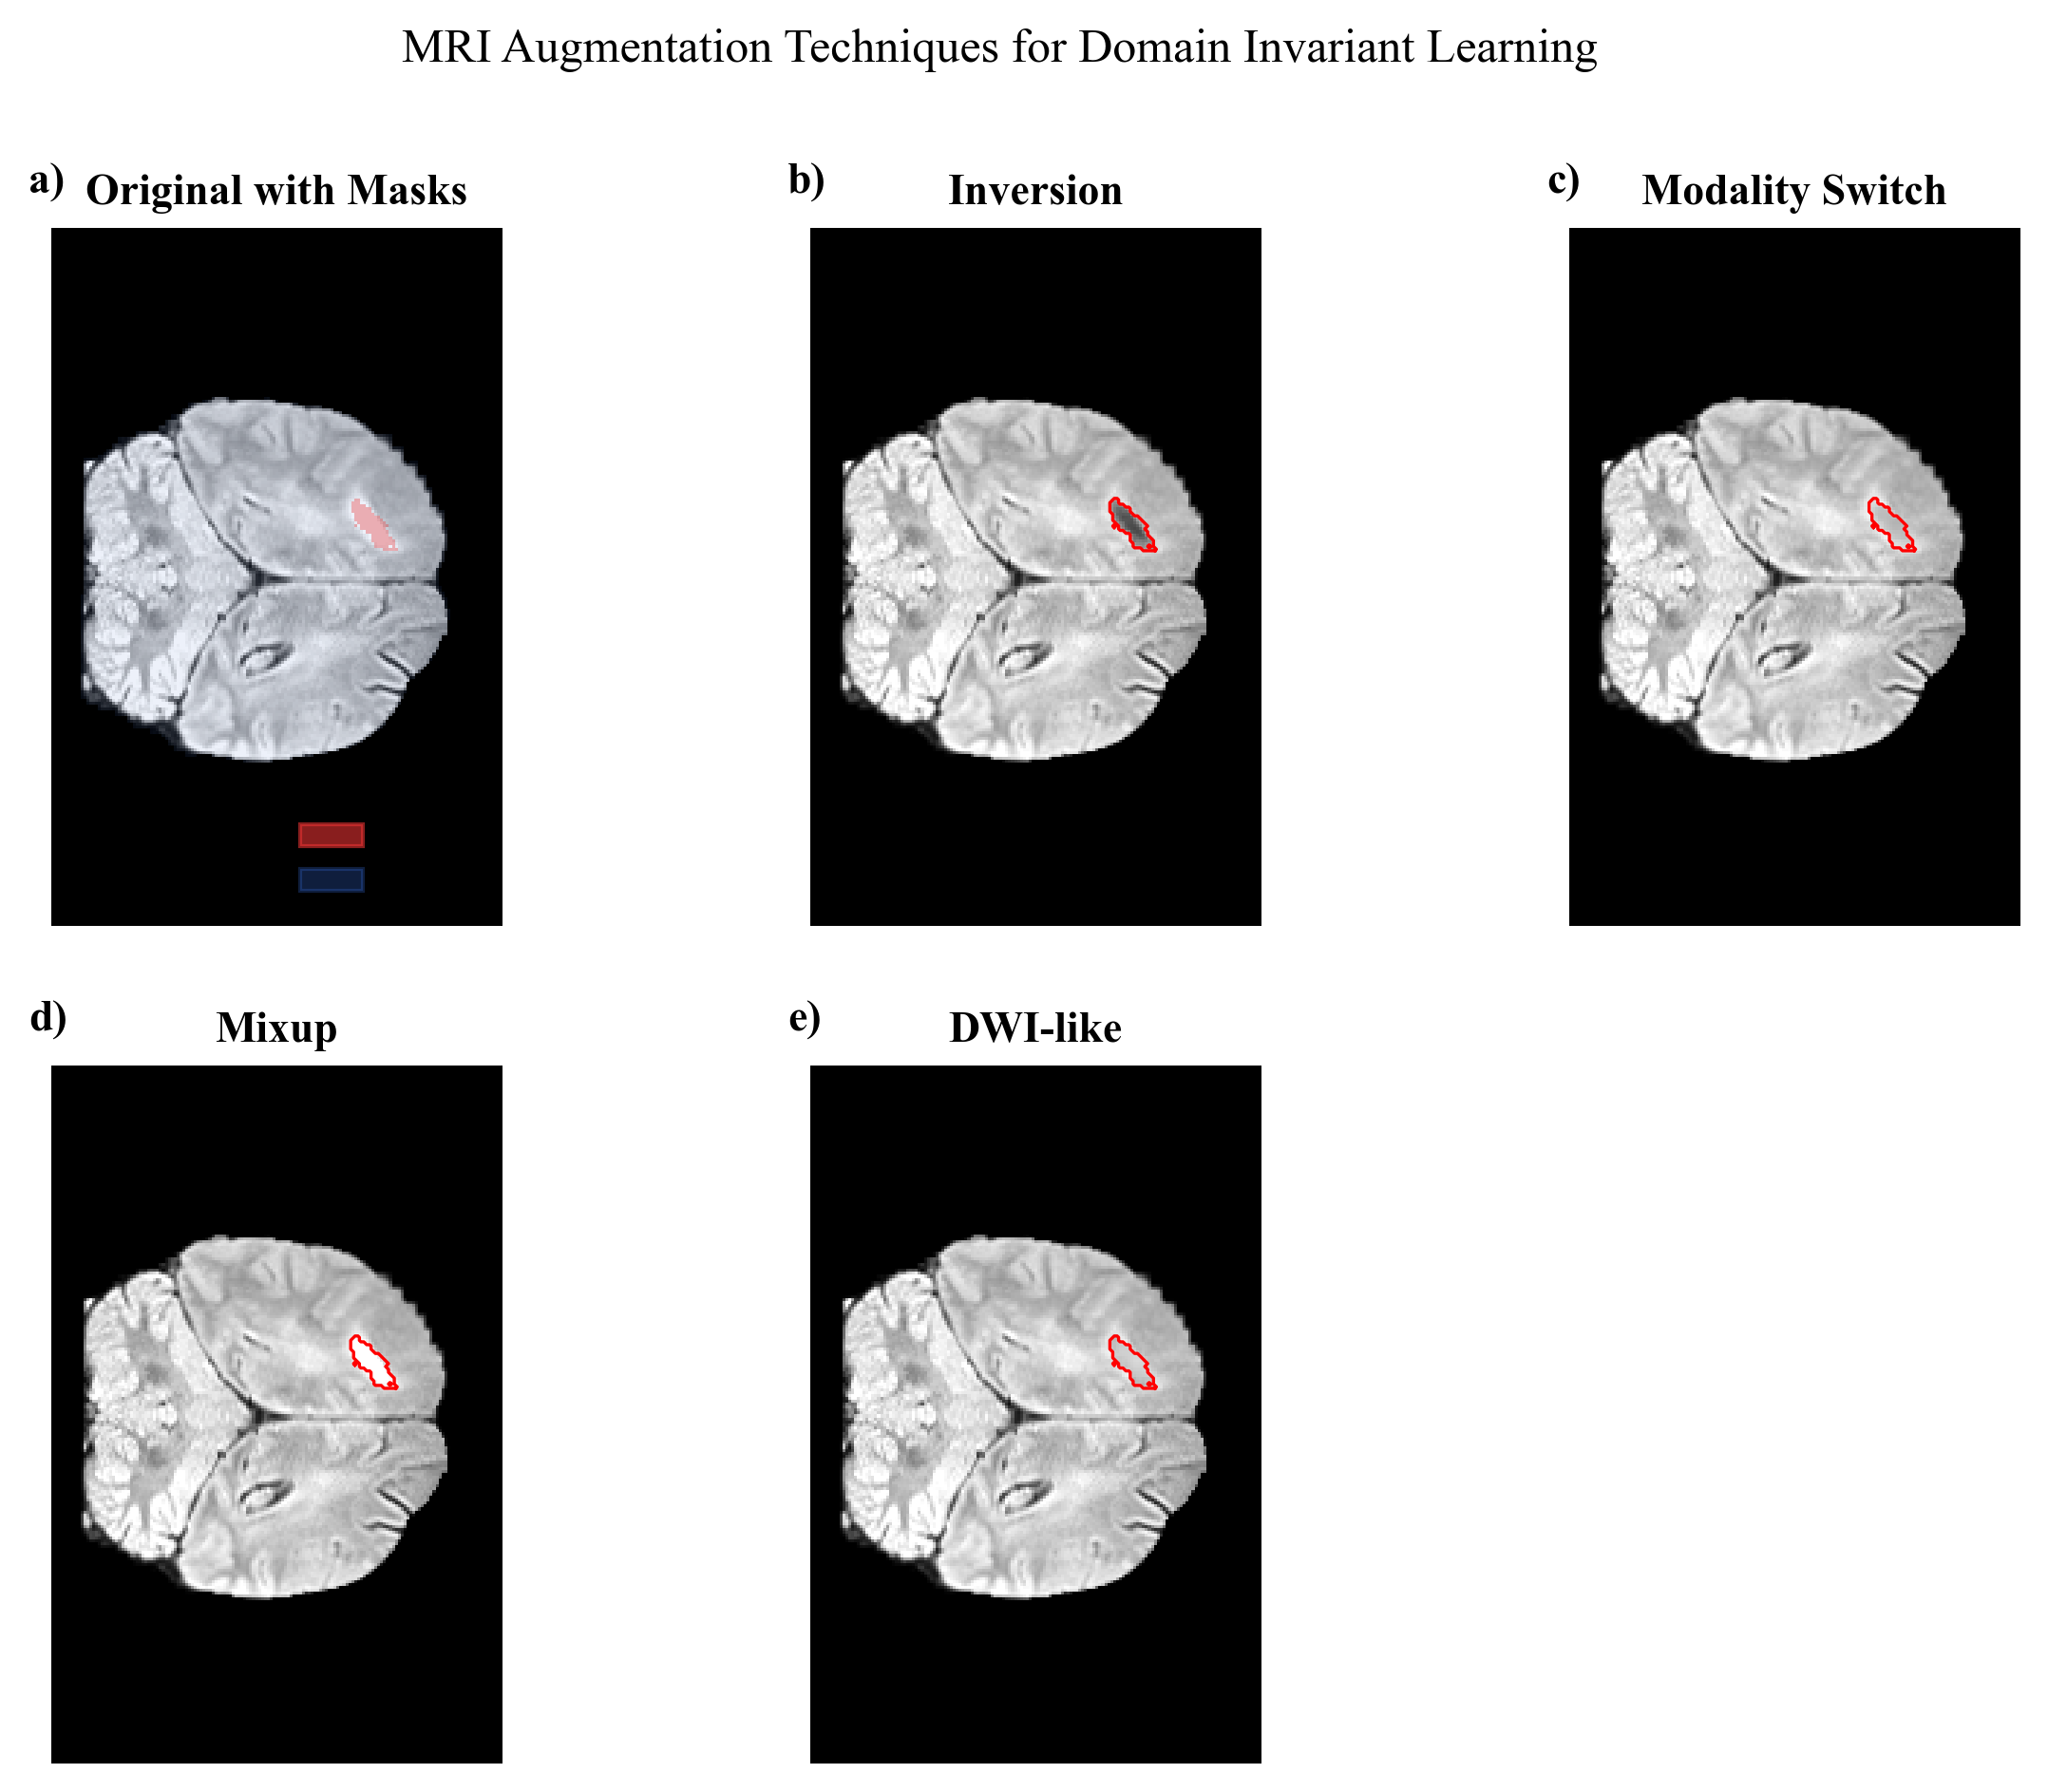

In [10]:
import torch
import nibabel as nib
import os
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import random
from config import Database_config, Augmentation_config
from augment_utils import spatial_contrast_aug

# Set publication-quality aesthetics
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'figure.dpi': 300
})

# Create custom colormaps for masks
tumor_cmap = LinearSegmentedColormap.from_list('tumor', 
                                              [(0, (0, 0, 0, 0)), 
                                               (1, (0.9, 0.2, 0.2, 0.6))])
brain_cmap = LinearSegmentedColormap.from_list('brain', 
                                              [(0, (0, 0, 0, 0)), 
                                               (1, (0.2, 0.4, 0.8, 0.3))])

# Load configs
database_config = Database_config()
aug_config = Augmentation_config()
torch.manual_seed(42)
random.seed(42)

# Choose a dataset with clear pathology
dataset = "BRATS"

# Get paths and files
img_path = database_config.img_path[dataset]
seg_path = database_config.seg_path[dataset]
mask_path = database_config.mask_path[dataset]
images = sorted(glob(os.path.join(img_path, "*.*")))
segs = sorted(glob(os.path.join(seg_path, "*.*")))
masks = sorted(glob(os.path.join(mask_path, "*.*")))

# Load a single subject with visible pathology
subject_idx = 10  # Adjust as needed

# Load data
img_nifti = nib.load(images[subject_idx])
seg_nifti = nib.load(segs[subject_idx])
mask_nifti = nib.load(masks[subject_idx])

# Convert to tensors
img_data = torch.from_numpy(img_nifti.get_fdata()).float()
seg_data = torch.from_numpy(seg_nifti.get_fdata()).float()
mask_data = torch.from_numpy(mask_nifti.get_fdata()).float()

# Reshape if needed
if img_data.dim() == 3:
    img_data = img_data.unsqueeze(0)
elif img_data.dim() == 4 and img_data.shape[0] > 10:
    img_data = img_data.permute(3, 0, 1, 2)

if seg_data.dim() == 3:
    seg_data = seg_data.unsqueeze(0)
    
if mask_data.dim() == 3:
    mask_data = mask_data.unsqueeze(0)

print(f"Image shape: {img_data.shape}")
print(f"Segmentation shape: {seg_data.shape}")
print(f"Brain mask shape: {mask_data.shape}")

# Find a good slice with pathology
good_slice = None
for i in range(seg_data.shape[2]):
    if seg_data[0, :, i, :].sum() > 100:
        good_slice = i
        break

if good_slice is None:
    good_slice = seg_data.shape[2] // 2

# Function to normalize images for visualization
def normalize_img(img, low_percentile=1, high_percentile=99):
    """Normalize image using percentiles to avoid outliers"""
    low, high = np.percentile(img, [low_percentile, high_percentile])
    img_norm = np.clip((img - low) / (high - low + 1e-5), 0, 1)
    return img_norm

# Setup augmentation configurations
aug_types = [
    {"name": "Original", "brain_invert": 0, "pathology_invert": 0, "pathology_switch": 0, "pathology_mixup": 0},
    {"name": "Inversion", "brain_invert": 0, "pathology_invert": 1.0, "pathology_switch": 0, "pathology_mixup": 0},
    {"name": "Modality Switch", "brain_invert": 0, "pathology_invert": 0, "pathology_switch": 1.0, "pathology_mixup": 0},
    {"name": "Mixup", "brain_invert": 0, "pathology_invert": 0, "pathology_switch": 0, "pathology_mixup": 1.0},
    {"name": "DWI-like", "brain_invert": 0.3, "pathology_invert": 0.7, "pathology_switch": 0.3, "pathology_mixup": 0.3}
]

# Create a neat 2x3 grid figure
fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(nrows=2, ncols=3, wspace=0.1, hspace=0.2)

# Process and display each augmentation
augmented_images = []

# First, create the original image with both tumor and brain masks
ax = fig.add_subplot(gs[0, 0])

# Get tumor and brain masks
tumor_mask = seg_data[0, :, good_slice, :].numpy() > 0
brain_mask = mask_data[0, :, good_slice, :].numpy() > 0

# Display original image
orig_img = normalize_img(img_data[0, :, good_slice, :].numpy())
ax.imshow(orig_img, cmap='gray')

# Overlay brain mask in blue (semi-transparent)
ax.imshow(brain_mask, cmap=brain_cmap, alpha=0.3)

# Overlay tumor mask in red (more visible)
ax.imshow(tumor_mask, cmap=tumor_cmap, alpha=0.6)

# Add legend
tumor_patch = patches.Patch(color=(0.9, 0.2, 0.2, 0.6), label='Tumor')
brain_patch = patches.Patch(color=(0.2, 0.4, 0.8, 0.3), label='Brain')
ax.legend(handles=[tumor_patch, brain_patch], loc='lower right', frameon=False, fontsize=8)

ax.set_title("Original with Masks", fontweight='bold')
ax.axis('off')

# Process and display each augmentation
for idx, aug in enumerate(aug_types[1:]):  # Skip original since we've shown it with masks
    # Configure augmentation
    aug_config.prob_brain_invert = aug["brain_invert"]
    aug_config.prob_pathology_invert = aug["pathology_invert"]
    aug_config.prob_pathology_switch = aug["pathology_switch"]
    aug_config.prob_pathology_mixup = aug["pathology_mixup"]
    
    # Apply augmentation
    augmented = spatial_contrast_aug(
        aug_config=aug_config,
        channel_add=[0],
        pathology_label=seg_data,
        brain_mask=mask_data,
        batch_img=img_data,
        plot_image=False
    )
    
    augmented_images.append(augmented)
    
    # Calculate position in grid (skip the first spot)
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    
    ax = fig.add_subplot(gs[row, col])
    
    # Normalize and display augmented image
    img_slice = augmented[0, :, good_slice, :].numpy()
    img_norm = normalize_img(img_slice)
    ax.imshow(img_norm, cmap='gray')
    
    # Add subtle tumor outline
    if True:  # For all augmented images
        try:
            # Add contour using skimage if available
            from skimage import measure
            contours = measure.find_contours(tumor_mask, 0.5)
            for contour in contours:
                ax.plot(contour[:, 1], contour[:, 0], linewidth=0.8, color='r')
        except ImportError:
            # Fallback if skimage is not available
            ax.contour(tumor_mask, levels=[0.5], colors=['r'], linewidths=0.8)
    
    # Clean up axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add title
    ax.set_title(aug["name"], fontweight='bold')

# Add subfigure labels
for i, ax in enumerate(fig.axes):
    ax.text(-0.05, 1.05, chr(97+i)+')', transform=ax.transAxes, 
            size=11, weight='bold')

# Add figure title
plt.suptitle("MRI Augmentation Techniques for Domain Invariant Learning", 
             fontsize=12, y=0.98)

# Save in high quality
plt.savefig('augmentation_grid_with_masks.png', dpi=600, bbox_inches='tight')
plt.savefig('augmentation_grid_with_masks.pdf', format='pdf', bbox_inches='tight')

plt.show()

Found large tumor (size 1926.0) in subject 15, slice 125


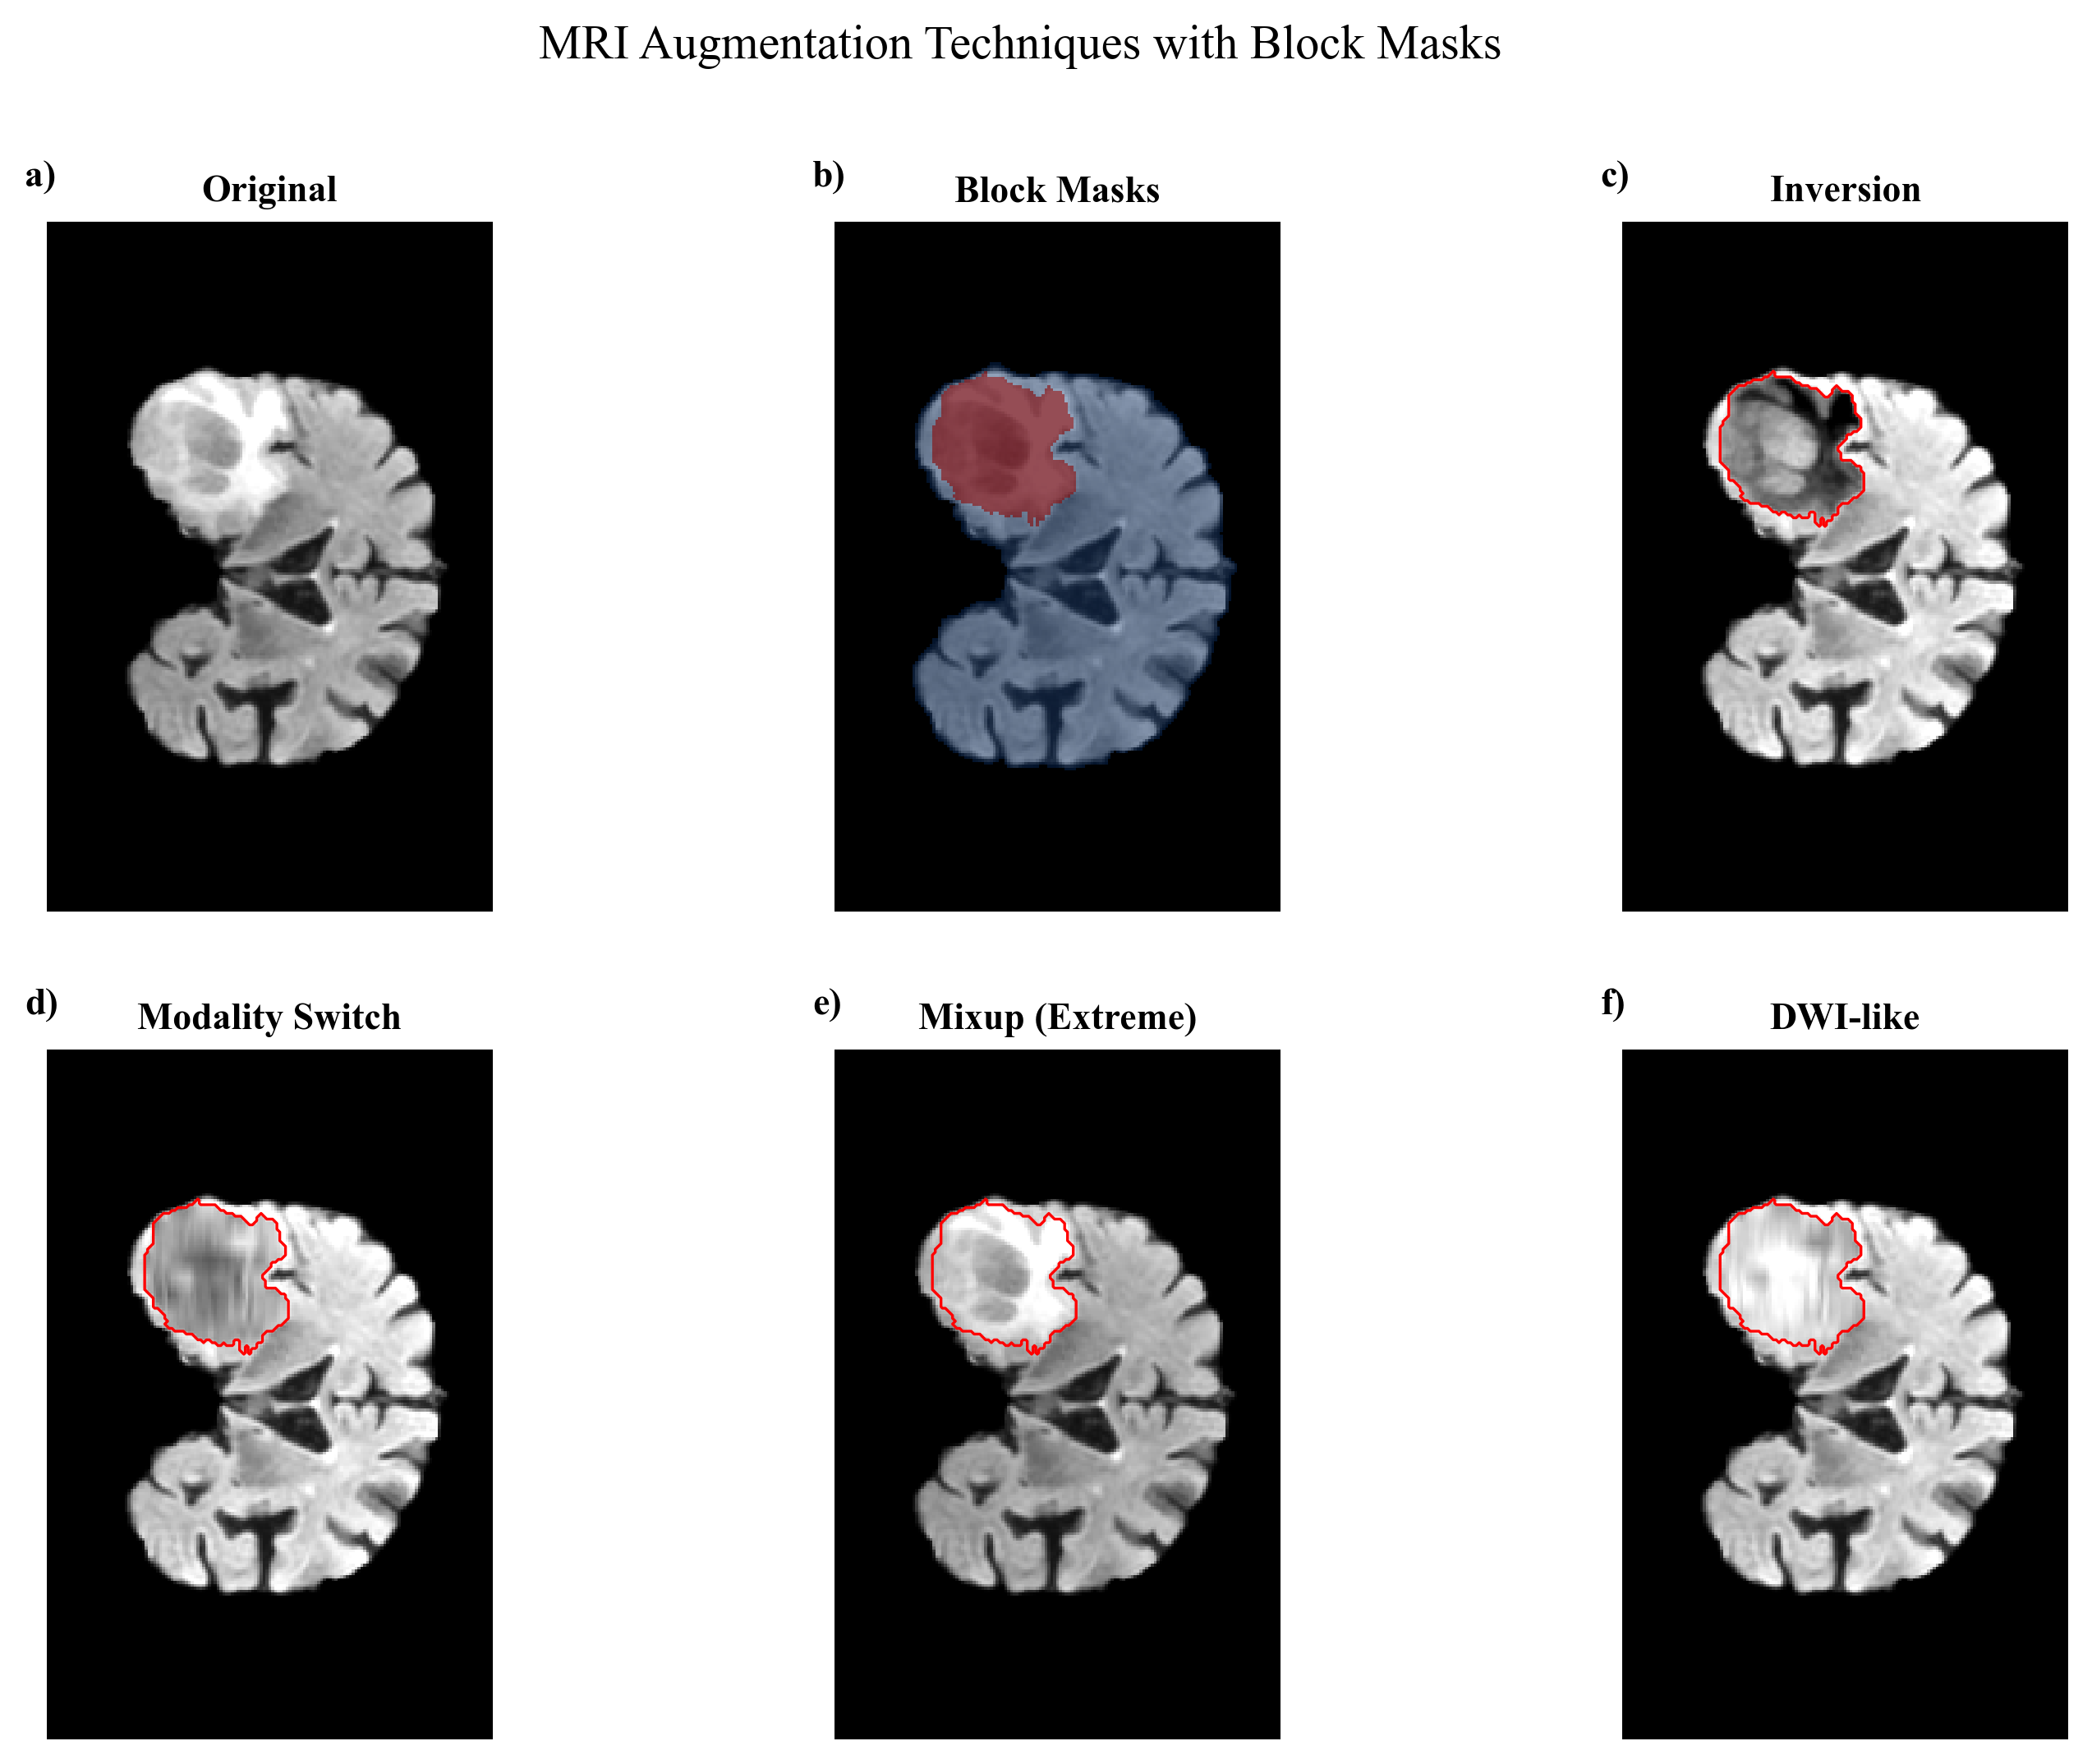

In [12]:
import torch
import nibabel as nib
import os
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import random
from config import Database_config, Augmentation_config
from augment_utils import spatial_contrast_aug

# Set publication aesthetics
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'figure.dpi': 300
})

# Load configs
database_config = Database_config()
aug_config = Augmentation_config()
torch.manual_seed(42)
random.seed(42)

# Choose BRATS dataset which has clear, large tumors
dataset = "BRATS"

# Get file paths
img_path = database_config.img_path[dataset]
seg_path = database_config.seg_path[dataset]
mask_path = database_config.mask_path[dataset]

# Find all files
images = sorted(glob(os.path.join(img_path, "*.*")))
segs = sorted(glob(os.path.join(seg_path, "*.*")))
masks = sorted(glob(os.path.join(mask_path, "*.*")))

# Find a subject with a large tumor
# Try multiple subjects to find one with a large tumor
for subject_idx in [15, 25, 10, 5, 30, 20]:  # Try these indices
    # Load data
    img_nifti = nib.load(images[subject_idx])
    seg_nifti = nib.load(segs[subject_idx])
    mask_nifti = nib.load(masks[subject_idx])
    
    # Convert to tensors
    img_data = torch.from_numpy(img_nifti.get_fdata()).float()
    seg_data = torch.from_numpy(seg_nifti.get_fdata()).float()
    mask_data = torch.from_numpy(mask_nifti.get_fdata()).float()
    
    # Reshape if needed
    if img_data.dim() == 3:
        img_data = img_data.unsqueeze(0)
    elif img_data.dim() == 4 and img_data.shape[0] > 10:
        img_data = img_data.permute(3, 0, 1, 2)
    
    if seg_data.dim() == 3:
        seg_data = seg_data.unsqueeze(0)
        
    if mask_data.dim() == 3:
        mask_data = mask_data.unsqueeze(0)
    
    # Find a slice with a large tumor
    largest_tumor_size = 0
    best_slice = None
    
    for i in range(seg_data.shape[2]):
        tumor_size = seg_data[0, :, i, :].sum().item()
        if tumor_size > largest_tumor_size:
            largest_tumor_size = tumor_size
            best_slice = i
    
    # If we found a good slice with a large tumor, break the loop
    if largest_tumor_size > 500:  # Adjust threshold as needed
        print(f"Found large tumor (size {largest_tumor_size}) in subject {subject_idx}, slice {best_slice}")
        break

# If we didn't find a good slice, use the best one we have
if best_slice is None:
    best_slice = seg_data.shape[2] // 2

# Function to normalize images for visualization
def normalize_img(img, low_percentile=1, high_percentile=99):
    """Normalize image using percentiles to avoid outliers"""
    low, high = np.percentile(img, [low_percentile, high_percentile])
    img_norm = np.clip((img - low) / (high - low + 1e-5), 0, 1)
    return img_norm

# Define more extreme augmentation settings
aug_types = [
    {"name": "Original", "brain_invert": 0, "pathology_invert": 0, "pathology_switch": 0, "pathology_mixup": 0},
    {"name": "Block Masks", "brain_invert": 0, "pathology_invert": 0, "pathology_switch": 0, "pathology_mixup": 0},  # Special case for masks
    {"name": "Inversion", "brain_invert": 0, "pathology_invert": 1.0, "pathology_switch": 0, "pathology_mixup": 0},
    {"name": "Modality Switch", "brain_invert": 0, "pathology_invert": 0, "pathology_switch": 1.0, "pathology_mixup": 0},
    {"name": "Mixup (Extreme)", "brain_invert": 0, "pathology_invert": 0, "pathology_switch": 0, "pathology_mixup": 1.0},
    {"name": "DWI-like", "brain_invert": 0.6, "pathology_invert": 1.0, "pathology_switch": 0.5, "pathology_mixup": 0.5}
]

# Create a 2×3 grid
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(nrows=2, ncols=3, wspace=0.1, hspace=0.2)

# Process and display each augmentation
augmented_images = []

# First, original image without any mask
ax = fig.add_subplot(gs[0, 0])
orig_img = normalize_img(img_data[0, :, best_slice, :].numpy())
ax.imshow(orig_img, cmap='gray')
ax.set_title("Original", fontweight='bold')
ax.axis('off')

# Second, image with block masks
ax = fig.add_subplot(gs[0, 1])
ax.imshow(orig_img, cmap='gray')

# Get masks
tumor_mask = seg_data[0, :, best_slice, :].numpy() > 0
brain_mask = mask_data[0, :, best_slice, :].numpy() > 0
healthy_brain_mask = brain_mask & (~tumor_mask)  # Only healthy brain tissue

# Create solid block masks
ax.imshow(np.ma.masked_where(~tumor_mask, np.ones_like(tumor_mask)), 
          cmap='Reds', alpha=0.7, vmin=0, vmax=1)
ax.imshow(np.ma.masked_where(~healthy_brain_mask, np.ones_like(healthy_brain_mask)), 
          cmap='Blues', alpha=0.4, vmin=0, vmax=1)

ax.set_title("Block Masks", fontweight='bold')
ax.axis('off')

# Process and display each augmentation
for idx, aug in enumerate(aug_types[2:]):  # Skip original and masks
    # Configure augmentation with extreme values
    aug_config.prob_brain_invert = aug["brain_invert"]
    aug_config.prob_pathology_invert = aug["pathology_invert"]
    aug_config.prob_pathology_switch = aug["pathology_switch"]
    aug_config.prob_pathology_mixup = aug["pathology_mixup"]
    
    # For Mixup, use extreme settings
    if "Mixup" in aug["name"]:
        # Try to set more extreme mixup values if your config allows it
        aug_config.prob_pathology_mixup = 1.0
        # If there are intensity parameters in your config, set them to extreme values
        if hasattr(aug_config, 'tumor_factor_multiply'):
            aug_config.tumor_factor_multiply = (1.5, 2.0)
        if hasattr(aug_config, 'tumor_factor_intensity'):
            aug_config.tumor_factor_intensity = (0.3, 0.6)
    
    # Apply augmentation
    augmented = spatial_contrast_aug(
        aug_config=aug_config,
        channel_add=[0],
        pathology_label=seg_data,
        brain_mask=mask_data,
        batch_img=img_data,
        plot_image=False
    )
    
    augmented_images.append(augmented)
    
    # Calculate position in grid (4 augmentations after original and mask)
    row = (idx + 2) // 3
    col = (idx + 2) % 3
    
    ax = fig.add_subplot(gs[row, col])
    
    # Normalize and display augmented image
    img_slice = augmented[0, :, best_slice, :].numpy()
    img_norm = normalize_img(img_slice)
    ax.imshow(img_norm, cmap='gray')
    
    # Add subtle tumor outline
    ax.contour(tumor_mask, levels=[0.5], colors=['r'], linewidths=0.8)
    
    # Clean up axes
    ax.axis('off')
    
    # Add title
    ax.set_title(aug["name"], fontweight='bold')

# Add subfigure labels
for i, ax in enumerate(fig.axes):
    ax.text(-0.05, 1.05, chr(97+i)+')', transform=ax.transAxes, 
            size=11, weight='bold')

# Add figure title
plt.suptitle("MRI Augmentation Techniques with Block Masks", 
             fontsize=14, y=0.98)

# Save in high quality
plt.savefig('augmentation_with_block_masks.png', dpi=600, bbox_inches='tight')
plt.savefig('augmentation_with_block_masks.pdf', format='pdf', bbox_inches='tight')

plt.show()